# Tic-Tac-Toe Q-learning — Python board

Run the code cell to train, inspect results, and play. The board is on the left; the AI's decision Q-values are on the right. Choose X or O, or press **New game**.

To explain it: **state** = board from the AI's view (0 empty, 1 AI, 2 you); **action** = empty cell; **reward** = +1 win, +0.3 draw, -1 loss; **Q-learning** updates move values after each game turn.

Default: 160,000 training games. The cell prints an opening-state Q-table for each human opening every 1,000 games, then a training table, opponent evaluation, and reward, success-rate, and steps plots. It also evaluates 1,000 games for each of the nine human opening squares, with a Q-table, results table, and comparison graph for those openings. The plots include Q-value progress and AI decisions for all nine openings. Expand the panels for full tables and Q-table snapshots, grouped by opening. Each AI move also updates a Q-value bar chart. Edit `EPISODES` or `OPENING_GAMES` for a shorter run. Requires Python 3.10+, Jupyter, `ipywidgets`, and Matplotlib.

Training complete: 160,000 games; final 1,000-game window: 97.0% non-loss, +0.517 mean reward.

Final evaluation (200 games as X and 200 as O per opponent)
Opponent    Wins  Draws  Losses  Non-loss
Random       377     23       0    100.0%
Tactical      56    344       0    100.0%
Minimax        0    400       0    100.0%

Human starts as X; AI is O. Each opening gets 1,000 games vs random X replies.
Q is learned future return, not a win probability. X marks the occupied cell.

Results by human opening (AI perspective; 1,000 games per row)
Opening       AI reply   Best Q   Wins  Draws Losses  Win rate
Top-left         (2,2)   +0.404    922     78      0     92.2%
Top              (2,2)   +0.418    937     63      0     93.7%
Top-right        (2,2)   +0.404    928     72      0     92.8%
Left             (2,2)   +0.418    936     64      0     93.6%
Center           (3,1)   +0.430    719    281      0     71.9%
Right            (2,2)   +0.418    942     58      0     94.2%
Bottom-left  

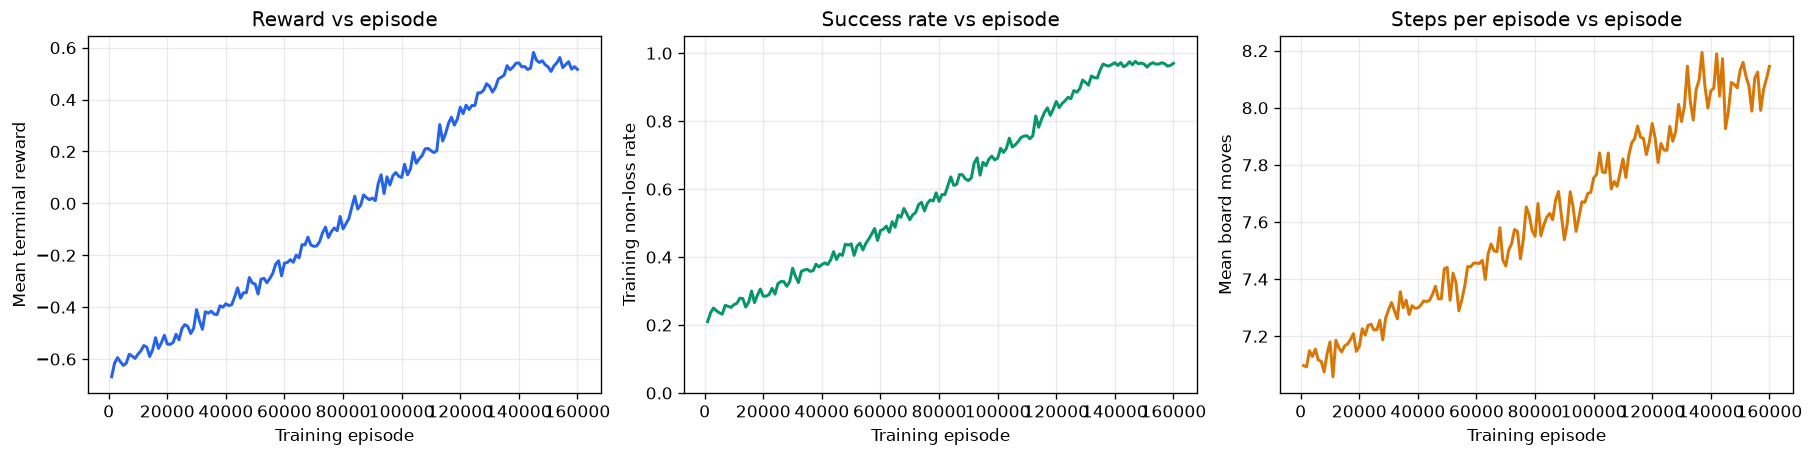


OPENING GRAPHS: outcomes and best AI Q-value by human first square


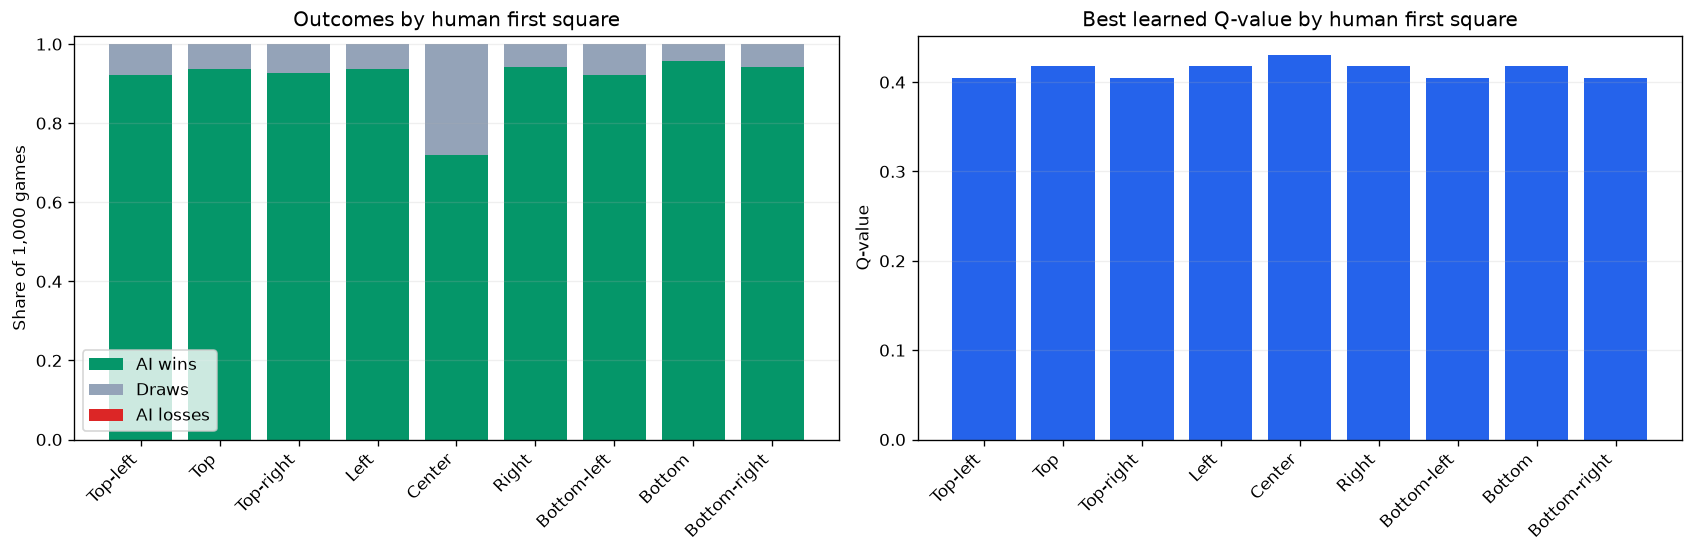


Q-VALUE PROGRESS: all nine human starting squares, measured every 1,000 games


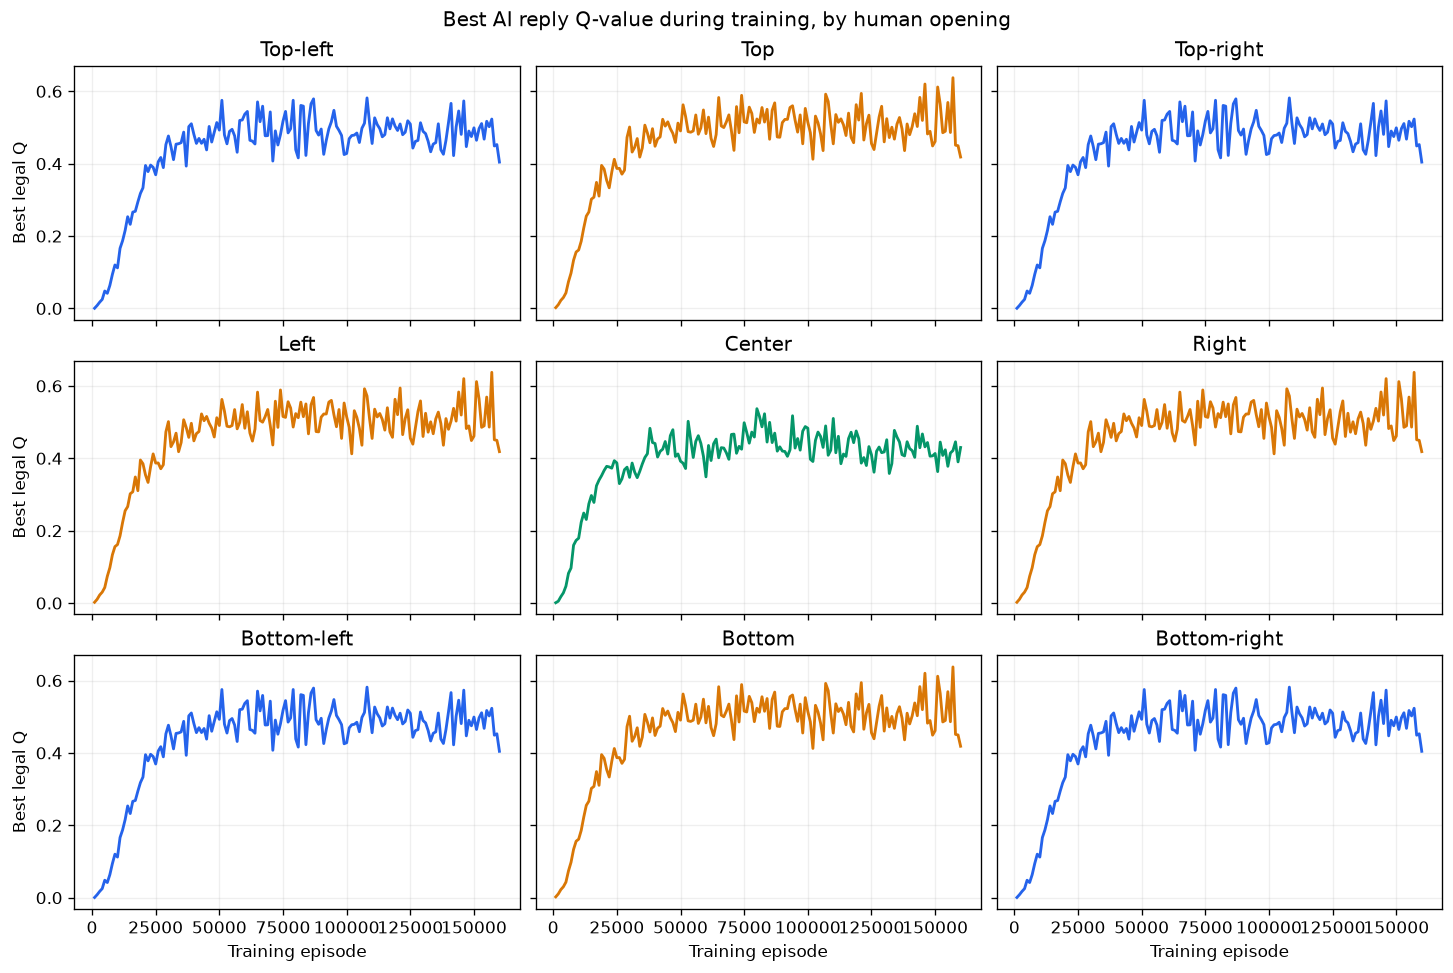


AI DECISION GRAPHS: all nine human starting squares


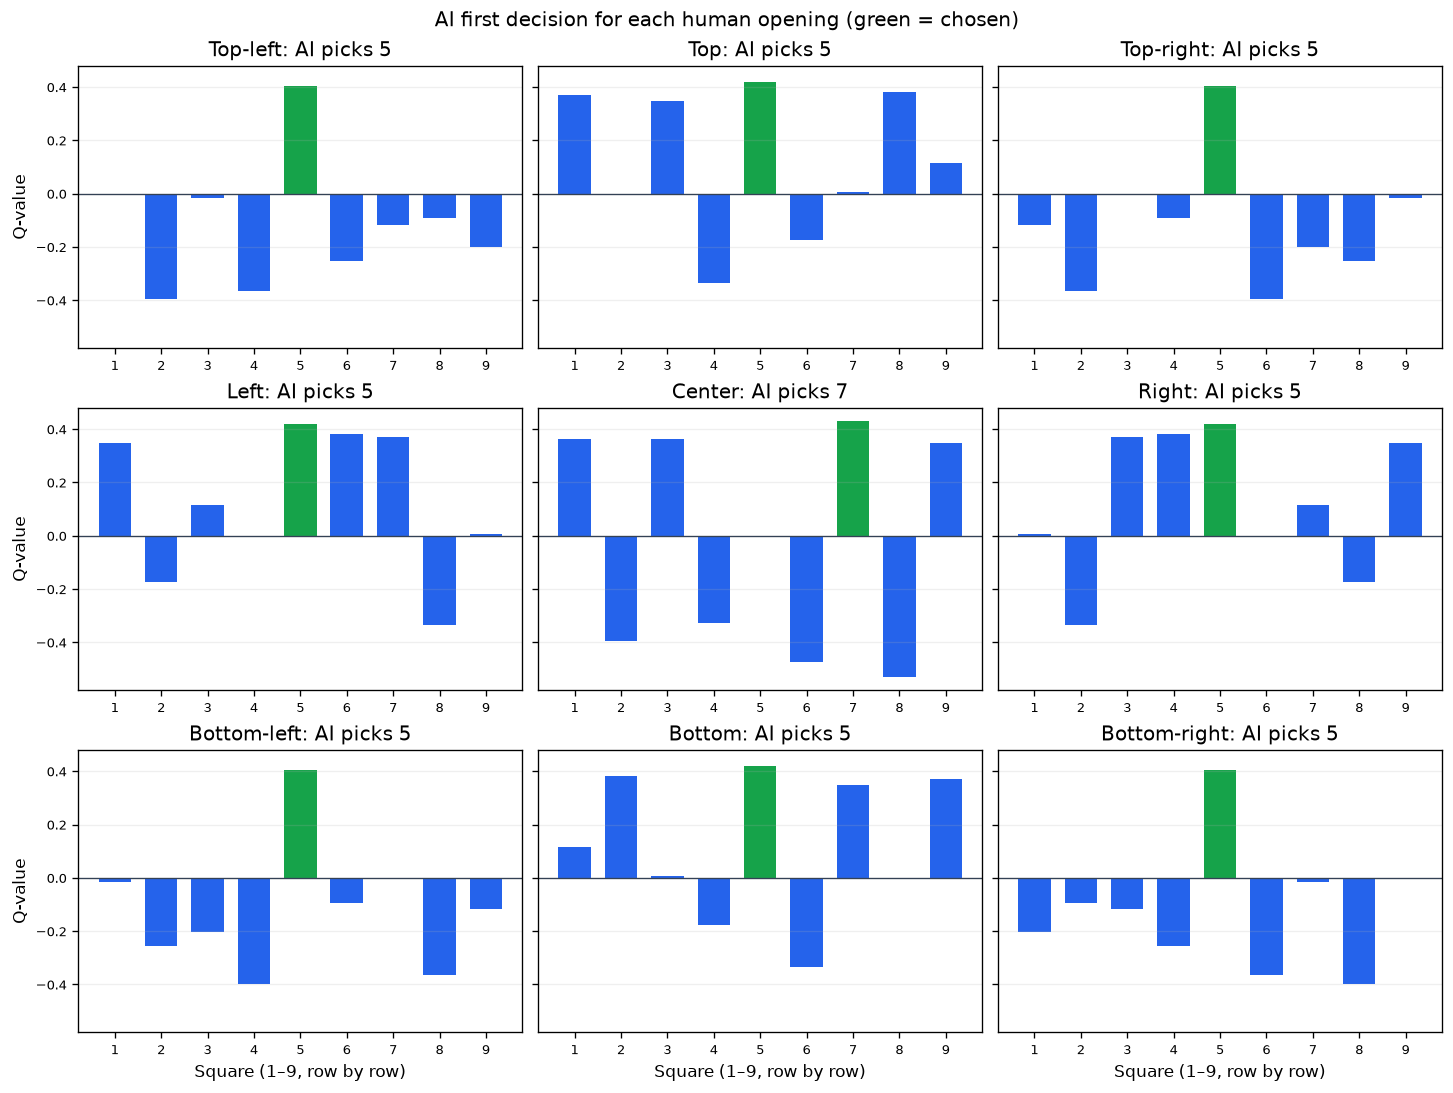

In [1]:
# One Python cell: train the Q-learning agent, then play it.
"""Game rules and opponents. Cells: 0 empty, 1 X, 2 O."""

from functools import lru_cache
import random
from typing import TypeAlias

Board: TypeAlias = tuple[int, ...]
X, O = 1, 2
EMPTY_BOARD: Board = (0,) * 9
WIN_LINES = ((0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6))


def legal_actions(board: Board) -> list[int]:
    """Return legal empty squares."""
    return [] if winner(board) else [i for i, mark in enumerate(board) if mark == 0]


@lru_cache(maxsize=None)
def winner(board: Board) -> int:
    for a, b, c in WIN_LINES:
        if board[a] and board[a] == board[b] == board[c]:
            return board[a]
    return 0


def terminal(board: Board) -> bool:
    return bool(winner(board)) or 0 not in board


def play(board: Board, action: int, mark: int) -> Board:
    if len(board) != 9 or mark not in (X, O):
        raise ValueError("Expected a nine-cell board and mark X=1 or O=2.")
    if terminal(board):
        raise ValueError("Cannot play after a terminal state.")
    if action not in range(9) or board[action] != 0:
        raise ValueError("Action must select an empty cell in 0..8.")
    return board[:action] + (mark,) + board[action + 1:]


def encode_state(board: Board, agent_mark: int) -> str:
    """Encode 0 empty, 1 agent, 2 opponent."""
    return "".join("0" if m == 0 else "1" if m == agent_mark else "2" for m in board)


def other(mark: int) -> int:
    return 3 - mark


def _symmetries() -> tuple[tuple[int, ...], ...]:
    # Rotate/reflect cell indices.
    result = []
    for reflection in (False, True):
        for rotations in range(4):
            permutation = []
            for i in range(9):
                r, c = divmod(i, 3)
                if reflection:
                    c = 2 - c
                for _ in range(rotations):
                    r, c = c, 2 - r
                permutation.append(3 * r + c)
            result.append(tuple(permutation))
    return tuple(result)


SYMMETRIES = _symmetries()


def transform_state(state: str, permutation: tuple[int, ...]) -> str:
    result = ["0"] * 9
    for i, j in enumerate(permutation):
        result[j] = state[i]
    return "".join(result)


@lru_cache(maxsize=None)
def canonicalize(state: str) -> tuple[str, tuple[int, ...]]:
    """Use one key for symmetric boards."""
    return min(((transform_state(state, p), p) for p in SYMMETRIES), key=lambda pair: pair[0])


@lru_cache(maxsize=None)
def minimax_value(board: Board, to_move: int) -> int:
    """Score perfect play for the current player."""
    won = winner(board)
    if won:
        return 1 if won == to_move else -1
    actions = legal_actions(board)
    if not actions:
        return 0
    return max(-minimax_value(play(board, a, to_move), other(to_move)) for a in actions)


@lru_cache(maxsize=None)
def minimax_actions(board: Board, mark: int) -> tuple[int, ...]:
    actions = legal_actions(board)
    if not actions:
        return ()
    values = [-minimax_value(play(board, a, mark), other(mark)) for a in actions]
    best = max(values)
    return tuple(a for a, v in zip(actions, values) if v == best)


def random_action(board: Board, mark: int, rng: random.Random) -> int:
    return rng.choice(legal_actions(board))


def minimax_action(board: Board, mark: int, rng: random.Random) -> int:
    return rng.choice(minimax_actions(board, mark))


def tactical_action(board: Board, mark: int, rng: random.Random) -> int:
    """Win, block, then prefer center or corners."""
    actions = legal_actions(board)
    for target in (mark, other(mark)):
        winning = [a for a in actions if winner(play(board, a, target)) == target]
        if winning:
            return rng.choice(winning)
    if 4 in actions:
        return 4
    corners = [a for a in actions if a in (0, 2, 6, 8)]
    return rng.choice(corners or actions)


OPPONENTS = {"random": random_action, "tactical": tactical_action, "minimax": minimax_action}


def mixture_action(board: Board, mark: int, rng: random.Random,
                   weights: tuple[float, float, float]) -> int:
    """Choose a training opponent each turn."""
    name = rng.choices(tuple(OPPONENTS), weights=weights, k=1)[0]
    return OPPONENTS[name](board, mark, rng)

"""Tabular Q-learning with board symmetry sharing."""

import json
from pathlib import Path
import random



class QLearningAgent:
    def __init__(self, alpha: float = 0.15, gamma: float = 0.97, seed: int = 42):
        self.alpha = alpha
        self.gamma = gamma
        self.rng = random.Random(seed)
        self.q: dict[str, list[float]] = {}

    def values(self, state: str) -> list[float]:
        key, permutation = canonicalize(state)
        values = self.q.get(key, [0.0] * 9)
        return [values[permutation[a]] for a in range(9)]

    def greedy_actions(self, board: Board, mark: int) -> list[int]:
        actions = legal_actions(board)
        if not actions:
            return []
        values = self.values(encode_state(board, mark))
        maximum = max(values[a] for a in actions)
        return [a for a in actions if abs(values[a] - maximum) <= 1e-12]

    def select_action(self, board: Board, agent_mark: int, epsilon: float = 0.0,
                      rng: random.Random | None = None) -> int:
        rng = rng or self.rng
        actions = legal_actions(board)
        if not actions:
            raise ValueError("No legal action in a terminal state.")
        if rng.random() < epsilon:
            return rng.choice(actions)
        return rng.choice(self.greedy_actions(board, agent_mark))

    def update(self, state: str, action: int, reward: float,
               next_state: str | None, done: bool) -> float:
        """Move Q toward reward plus the best legal next value."""
        if state[action] != "0":
            raise ValueError("Cannot learn an illegal action.")
        key, permutation = canonicalize(state)
        values = self.q.setdefault(key, [0.0] * 9)
        canonical_action = permutation[action]
        target = reward
        if not done:
            if next_state is None:
                raise ValueError("A nonterminal update needs a next state.")
            next_values = self.values(next_state)
            actions = [a for a, cell in enumerate(next_state) if cell == "0"]
            if not actions:
                raise ValueError("A nonterminal next state needs a legal action.")
            target += self.gamma * max(next_values[a] for a in actions)
        td_error = target - values[canonical_action]
        values[canonical_action] += self.alpha * td_error
        return abs(td_error)



# Train: try moves early, then favor learned moves.
import ipywidgets as widgets
from IPython.display import Image, display
import matplotlib.pyplot as plt
from io import BytesIO

def figure_png(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, facecolor="white", bbox_inches="tight")
    plt.close(fig)
    return buffer.getvalue()

EPISODES = 160_000
SEED = 42
agent = QLearningAgent(alpha=0.15, gamma=0.97, seed=SEED)
opponent_rng = random.Random(SEED + 1)
opponent_weights = (0.25, 0.15, 0.60)  # random, tactical, minimax
history = []
start_names = ("Top-left", "Top", "Top-right", "Left", "Center",
               "Right", "Bottom-left", "Bottom", "Bottom-right")
opening_q_history = []
window = {"wins": 0, "draws": 0, "losses": 0, "reward": 0.0, "moves": 0}
q_logs = [widgets.Output(layout=widgets.Layout(max_height="320px", overflow="auto"))
          for _ in range(9)]
training_table = widgets.Output(layout=widgets.Layout(max_height="320px", overflow="auto"))
opening_q_log = widgets.Output(layout=widgets.Layout(max_height="320px", overflow="auto"))

def q_snapshot(episode, start, name):
    board = play(EMPTY_BOARD, start, X)
    values = agent.values(encode_state(board, O))
    best = agent.greedy_actions(board, O)
    lines = [f"Episode {episode:,} | human X at {name}, AI O to move | states: {len(agent.q)}"]
    for row in range(0, 9, 3):
        lines.append("  " + " | ".join("   X   " if board[i] else f"{values[i]:+.3f}"
                                      for i in range(row, row + 3)))
    replies = ", ".join(f"({i // 3 + 1},{i % 3 + 1})" for i in best)
    lines.append(f"  Best AI reply: {replies} | Q = {values[best[0]]:+.3f}\n")
    return "\n".join(lines), values[best[0]]

for episode in range(1, EPISODES + 1):
    agent_mark = X if episode % 2 else O
    board = EMPTY_BOARD
    moves = 0
    if agent_mark == O:
        board = play(board, mixture_action(board, X, opponent_rng, opponent_weights), X)
        moves += 1
    # Epsilon falls from 1.0 to 0.03.
    fraction = min(1.0, (episode - 1) / max(1, EPISODES * 0.85))
    epsilon = 1.0 + fraction * (0.03 - 1.0)
    while True:
        state = encode_state(board, agent_mark)
        action = agent.select_action(board, agent_mark, epsilon)
        board = play(board, action, agent_mark)
        moves += 1
        if not terminal(board):
            opponent_mark = other(agent_mark)
            reply = mixture_action(board, opponent_mark, opponent_rng, opponent_weights)
            board = play(board, reply, opponent_mark)
            moves += 1
        done = terminal(board)
        result = winner(board)
        # Reward: win +1, draw +0.3, loss -1.
        reward = ((1.0 if result == agent_mark else -1.0) if result else 0.3) if done else 0.0
        agent.update(state, action, reward,
                     None if done else encode_state(board, agent_mark), done)
        if done:
            break

    window["wins"] += result == agent_mark
    window["draws"] += result == 0
    window["losses"] += result == other(agent_mark)
    window["reward"] += reward
    window["moves"] += moves
    if episode % 1000 == 0 or episode == EPISODES:
        count = episode % 1000 or 1000
        history.append({"episode": episode, "epsilon": epsilon,
                        "avg_reward": window["reward"] / count,
                        "non_loss": (window["wins"] + window["draws"]) / count,
                        "avg_moves": window["moves"] / count,
                        "wins": window["wins"], "draws": window["draws"],
                        "losses": window["losses"]})
        best_values = []
        for start, name in enumerate(start_names):
            snapshot, best_q = q_snapshot(episode, start, name)
            q_logs[start].append_stdout(snapshot)
            best_values.append(best_q)
        opening_q_history.append({"episode": episode, "best_values": best_values})
        window = {"wins": 0, "draws": 0, "losses": 0, "reward": 0.0, "moves": 0}

table_lines = ["Training results by 1,000-game window",
               f"{'Episode':>8} {'eps':>6} {'W':>5} {'D':>5} {'L':>5} {'avg reward':>11} {'non-loss':>9} {'moves':>7}"]
for row in history:
    table_lines.append(f"{row['episode']:8,d} {row['epsilon']:6.3f} {row['wins']:5d} "
                       f"{row['draws']:5d} {row['losses']:5d} {row['avg_reward']:11.3f} "
                       f"{row['non_loss']:9.1%} {row['avg_moves']:7.2f}")
training_table.append_stdout("\n".join(table_lines) + "\n")
print(f"Training complete: {EPISODES:,} games; final 1,000-game window: "
      f"{history[-1]['non_loss']:.1%} non-loss, {history[-1]['avg_reward']:+.3f} mean reward.")

# Evaluate the greedy policy against each opponent.
print("\nFinal evaluation (200 games as X and 200 as O per opponent)")
print(f"{'Opponent':<10} {'Wins':>5} {'Draws':>6} {'Losses':>7} {'Non-loss':>9}")
for name, weights in (("Random", (1, 0, 0)), ("Tactical", (0, 1, 0)),
                      ("Minimax", (0, 0, 1))):
    eval_rng = random.Random(SEED + 100)
    wins = draws = losses = 0
    for game_number in range(400):
        agent_mark = X if game_number % 2 == 0 else O
        board = EMPTY_BOARD
        while not terminal(board):
            turn = X if sum(cell != 0 for cell in board) % 2 == 0 else O
            action = (agent.select_action(board, agent_mark, rng=eval_rng)
                      if turn == agent_mark else mixture_action(board, turn, eval_rng, weights))
            board = play(board, action, turn)
        result = winner(board)
        wins += result == agent_mark
        draws += result == 0
        losses += result == other(agent_mark)
    print(f"{name:<10} {wins:5d} {draws:6d} {losses:7d} {(wins + draws) / 400:9.1%}")

# Compare all nine human openings with the same trained AI.
OPENING_GAMES = 1000
opening_results = []
print("\nHuman starts as X; AI is O. Each opening gets 1,000 games vs random X replies.")
print("Q is learned future return, not a win probability. X marks the occupied cell.")
for start, name in enumerate(start_names):
    first_board = play(EMPTY_BOARD, start, X)
    q_values = agent.values(encode_state(first_board, O))
    best = agent.greedy_actions(first_board, O)
    category_rng = random.Random(SEED + 1000 + start)
    wins = draws = losses = 0
    for _ in range(OPENING_GAMES):
        board = first_board
        while not terminal(board):
            turn = X if sum(cell != 0 for cell in board) % 2 == 0 else O
            action = (agent.select_action(board, O, rng=category_rng) if turn == O
                      else mixture_action(board, X, category_rng, (1, 0, 0)))
            board = play(board, action, turn)
        result = winner(board)
        wins += result == O
        draws += result == 0
        losses += result == X
    opening_results.append({"start": name, "best_reply": best[0],
                            "best_q": q_values[best[0]], "wins": wins,
                            "draws": draws, "losses": losses})
    q_lines = [f"\n{name}: human X at ({start // 3 + 1},{start % 3 + 1})"]
    for row in range(0, 9, 3):
        q_lines.append("  " + " | ".join("   X   " if first_board[i] else f"{q_values[i]:+.3f}"
                                           for i in range(row, row + 3)))
    q_lines.append(f"  Best AI reply: ({best[0] // 3 + 1},{best[0] % 3 + 1}), "
                   f"Q = {q_values[best[0]]:+.3f}; outcomes: {wins} W / {draws} D / {losses} L\n")
    opening_q_log.append_stdout("\n".join(q_lines))

print("\nResults by human opening (AI perspective; 1,000 games per row)")
print(f"{'Opening':<13} {'AI reply':>8} {'Best Q':>8} {'Wins':>6} {'Draws':>6} "
      f"{'Losses':>6} {'Win rate':>9}")
for row in opening_results:
    action = row["best_reply"]
    print(f"{row['start']:<13} {f'({action // 3 + 1},{action % 3 + 1})':>8} "
          f"{row['best_q']:+8.3f} {row['wins']:6d} {row['draws']:6d} "
          f"{row['losses']:6d} {row['wins'] / OPENING_GAMES:9.1%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.7), constrained_layout=True)
xs = [row["episode"] for row in history]
for ax, key, title, ylabel, color in zip(
    axes,
    ("avg_reward", "non_loss", "avg_moves"),
    ("Reward vs episode", "Success rate vs episode", "Steps per episode vs episode"),
    ("Mean terminal reward", "Training non-loss rate", "Mean board moves"),
    ("#2563eb", "#059669", "#d97706"),
):
    ax.plot(xs, [row[key] for row in history], color=color, linewidth=1.8)
    ax.set(title=title, xlabel="Training episode", ylabel=ylabel)
    ax.grid(alpha=0.25)
axes[1].set_ylim(0, 1.05)
print("\nTRAINING PLOTS: reward, success rate, and steps versus episode")
display(Image(data=figure_png(fig)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
positions = list(range(9))
win_rates = [row["wins"] / OPENING_GAMES for row in opening_results]
draw_rates = [row["draws"] / OPENING_GAMES for row in opening_results]
loss_rates = [row["losses"] / OPENING_GAMES for row in opening_results]
axes[0].bar(positions, win_rates, label="AI wins", color="#059669")
axes[0].bar(positions, draw_rates, bottom=win_rates, label="Draws", color="#94a3b8")
axes[0].bar(positions, loss_rates, bottom=[w + d for w, d in zip(win_rates, draw_rates)],
            label="AI losses", color="#dc2626")
axes[0].set(title="Outcomes by human first square", ylabel="Share of 1,000 games", ylim=(0, 1.02))
axes[0].legend()
axes[1].bar(positions, [row["best_q"] for row in opening_results], color="#2563eb")
axes[1].set(title="Best learned Q-value by human first square", ylabel="Q-value")
for ax in axes:
    ax.set_xticks(positions, start_names, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.2)
print("\nOPENING GRAPHS: outcomes and best AI Q-value by human first square")
display(Image(data=figure_png(fig)))

fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True,
                         constrained_layout=True)
for start, ax in enumerate(axes.flat):
    color = "#2563eb" if start in (0, 2, 6, 8) else "#d97706" if start != 4 else "#059669"
    ax.plot([row["episode"] for row in opening_q_history],
            [row["best_values"][start] for row in opening_q_history],
            color=color, linewidth=1.7)
    ax.set_title(start_names[start])
    ax.grid(alpha=0.2)
    if start >= 6:
        ax.set_xlabel("Training episode")
    if start % 3 == 0:
        ax.set_ylabel("Best legal Q")
fig.suptitle("Best AI reply Q-value during training, by human opening")
print("\nQ-VALUE PROGRESS: all nine human starting squares, measured every 1,000 games")
display(Image(data=figure_png(fig)))

q_tabs = widgets.Tab(children=q_logs)
for start, name in enumerate(start_names):
    q_tabs.set_title(start, name)
details = widgets.Accordion(children=[training_table, q_tabs, opening_q_log], selected_index=None)
for index, title in enumerate(("Full training table", "Q-table every 1,000 games",
                               "Q-tables for each human opening")):
    details.set_title(index, title)
display(details)

def draw_decision_bars(ax, board, values, selected):
    # One bar per square; occupied squares have no legal Q-value.
    ax.set_facecolor("white")
    colors = ["#cbd5e1" if board[i] else "#16a34a" if i == selected else "#2563eb"
              for i in range(9)]
    heights = [values[i] if board[i] == 0 else 0 for i in range(9)]
    ax.bar(range(1, 10), heights, color=colors, width=0.7)
    ax.axhline(0, color="#334155", linewidth=0.8)
    ax.set_xticks(range(1, 10))
    ax.set(title="AI decision: green = chosen", xlabel="Square (1–9, row by row)", ylabel="Q-value")
    ax.tick_params(labelsize=8, colors="black")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.grid(axis="y", alpha=0.2)
    return ax

def decision_figure(board, values, selected):
    fig, ax = plt.subplots(figsize=(3.25, 2.35), dpi=110)
    fig.patch.set_facecolor("white")
    draw_decision_bars(ax, board, values, selected)
    fig.tight_layout()
    return fig

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharey=True, constrained_layout=True)
for start, ax in enumerate(axes.flat):
    board = play(EMPTY_BOARD, start, X)
    values = agent.values(encode_state(board, O))
    selected = agent.greedy_actions(board, O)[0]
    draw_decision_bars(ax, board, values, selected)
    ax.set_title(f"{start_names[start]}: AI picks {selected + 1}")
    if start < 6:
        ax.set_xlabel("")
    if start % 3:
        ax.set_ylabel("")
fig.suptitle("AI first decision for each human opening (green = chosen)")
print("\nAI DECISION GRAPHS: all nine human starting squares")
display(Image(data=figure_png(fig)))


class NotebookTicTacToe:
    def __init__(self, trained_agent):
        self.agent = trained_agent
        self.board = EMPTY_BOARD
        self.human_mark = X
        self.agent_mark = O
        self.finished = False

        self.title = widgets.Label(value="TIC TAC TOE  ·  Q-LEARNING")
        self.status = widgets.Label()
        self.play_x = widgets.Button(description="Play as X", layout=widgets.Layout(width="120px"))
        self.play_o = widgets.Button(description="Play as O", layout=widgets.Layout(width="120px"))
        self.play_x.on_click(lambda _: self._change_side(X))
        self.play_o.on_click(lambda _: self._change_side(O))
        self.side = widgets.HBox([self.play_x, self.play_o])
        self.new_game = widgets.Button(description="New game", icon="refresh")
        self.new_game.on_click(lambda _: self.reset())

        self.cells = []
        for position in range(9):
            button = widgets.Button(
                description="", layout=widgets.Layout(width="82px", height="82px"),
            )
            button.style.font_weight = "bold"
            button.style.font_size = "34px"
            button.on_click(lambda _, index=position: self.human_move(index))
            self.cells.append(button)

        self.q_title = widgets.Label(value="Q-values at the AI's decision")
        self.q_state = widgets.Label(value="Make a move to see the Q-table.")
        self.q_choice = widgets.Label(value="0 = empty · 1 = AI · 2 = you")
        self.decision_chart = widgets.Image(format="png",
                                            layout=widgets.Layout(width="330px"))
        self.q_cells = [widgets.Button(
            description="—", layout=widgets.Layout(width="92px", height="52px"),
        ) for _ in range(9)]
        for button in self.q_cells:
            button.style.font_size = "14px"
            button.style.font_weight = "bold"
            button.tooltip = "Q value at the AI's last decision"

        # Notebook dark themes can override ButtonStyle.text_color.
        self.font_fix = widgets.HTML(value="""<style>
        .rl-black-text, .rl-black-text *, button.rl-black-text {
            color: #000 !important;
            -webkit-text-fill-color: #000 !important;
        }
        </style>""")
        for button in (self.play_x, self.play_o, self.new_game, *self.cells, *self.q_cells):
            button.add_class("rl-black-text")
            button.style.text_color = "#000000"

        board_grid = widgets.GridBox(
            self.cells,
            layout=widgets.Layout(grid_template_columns="repeat(3, 82px)", grid_gap="5px"),
        )
        q_grid = widgets.GridBox(
            self.q_cells,
            layout=widgets.Layout(grid_template_columns="repeat(3, 92px)", grid_gap="5px"),
        )
        left = widgets.VBox([self.font_fix, self.title, self.side, self.status, board_grid, self.new_game])
        right = widgets.VBox([self.q_title, self.q_state, q_grid,
                              self.q_choice, self.decision_chart])
        self.widget = widgets.HBox(
            [left, right],
            layout=widgets.Layout(flex_flow="row wrap", gap="32px", align_items="flex-start"),
        )
        self.reset()

    def _change_side(self, mark):
        self.human_mark = mark
        self.agent_mark = other(mark)
        self.reset()

    def _draw_side(self):
        for button, mark in ((self.play_x, X), (self.play_o, O)):
            chosen = mark == self.human_mark
            button.style.button_color = "#50d99a" if chosen else "#f8fafc"
            button.style.text_color = "#000000"
            button.style.font_weight = "bold"

    def _draw_board(self):
        for index, button in enumerate(self.cells):
            mark = self.board[index]
            button.description = "X" if mark == X else "O" if mark == O else ""
            button.style.button_color = "#72e0a6" if mark == X else "#ffbe73" if mark == O else "#f8fafc"
            button.style.text_color = "#000000"
            button.tooltip = "Empty square" if mark == 0 else "Occupied square"

    def _finish_or_continue(self):
        result = winner(self.board)
        if result or terminal(self.board):
            self.finished = True
            self.status.value = (
                "You win!" if result == self.human_mark else
                "AI wins!" if result == self.agent_mark else "Draw!"
            )
        else:
            self.status.value = "Your turn. Choose an empty square."
        self._draw_board()

    def reset(self):
        self.board = EMPTY_BOARD
        self.finished = False
        self._draw_side()
        self.q_state.value = "Make a move to see the Q-table."
        self.q_choice.value = "0 = empty · 1 = AI · 2 = you"
        self.decision_chart.value = b""
        for button in self.q_cells:
            button.description = "—"
            button.style.button_color = "#f8fafc"
            button.style.text_color = "#000000"
        self.status.value = "Your turn. Choose an empty square."
        self._draw_board()
        if self.agent_mark == X:
            self._agent_move()

    def human_move(self, index):
        if self.finished or self.board[index] != 0:
            return
        self.board = play(self.board, index, self.human_mark)
        if terminal(self.board):
            self._finish_or_continue()
        else:
            self._agent_move()

    def _agent_move(self):
        # Show Q-values before the AI places its mark.
        before = self.board
        state = encode_state(before, self.agent_mark)
        values = self.agent.values(state)
        selected = self.agent.select_action(before, self.agent_mark, epsilon=0.0)
        self.q_state.value = "State: " + state + "  (AI's view)"
        for index, button in enumerate(self.q_cells):
            button.description = "occupied" if before[index] != 0 else f"{values[index]:+.3f}"
            button.style.button_color = (
                "#72e0a6" if index == selected else
                "#dbe4ea" if before[index] != 0 else "#f8fafc"
            )
            button.style.text_color = "#000000"
        row, col = divmod(selected, 3)
        self.q_choice.value = (
            f"AI chose row {row + 1}, column {col + 1} · Q = {values[selected]:+.3f}"
        )
        fig = decision_figure(before, values, selected)
        self.decision_chart.value = figure_png(fig)
        self.board = play(before, selected, self.agent_mark)
        self._finish_or_continue()


game = NotebookTicTacToe(agent)
display(game.widget)
